In [85]:
pt_file = 'attack_results/Cora-11_netattack.pt'
attack_data = torch.load(pt_file)
data = attack_data[0]


In [87]:
perturb = data['perturbations'][0]
adj = perturb["modified_adj"]
feat = perturb["modified_features"]
perturb

{'target_node': 1245,
 'modified_adj': <2485x2485 sparse matrix of type '<class 'numpy.float64'>'
 	with 10140 stored elements in List of Lists format>,
 'modified_features': <2485x1433 sparse matrix of type '<class 'numpy.float32'>'
 	with 45487 stored elements in List of Lists format>}

In [127]:
for per in attack_data:
    i = 1
    for t in per['perturbations']:
        target_node = t['target_node']
        mod_adj, mod_feat = t['modified_adj'], t['modified_features']
        print(target_node)
        print(mod_adj[1245])
        break
    break

1245
  (0, 145)	1.0
  (0, 542)	1.0
  (0, 1353)	1.0
  (0, 2483)	1.0


In [78]:
from scipy.sparse import lil_matrix
import numpy as np

def normalize_lil_rows(feat_lil):
    feat = feat_lil.tocsr()  # convert to CSR for fast row operations

    row_sums = np.array(feat.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1  # avoid division by zero

    # Divide each row by its sum
    feat = feat.multiply(1 / row_sums[:, np.newaxis])

    return feat.tolil()  # convert back to LIL if needed

normalize_lil_rows(feat)

<2485x1433 sparse matrix of type '<class 'numpy.float32'>'
	with 45487 stored elements in List of Lists format>

In [83]:
from torch_geometric.datasets import Planetoid

from deeprobust.graph.utils import get_train_val_test

def split_data(data, seed):
    train_idx, val_idx, test_idx = get_train_val_test(
        data.num_nodes, stratify=data.y, seed=seed)

    # Create boolean masks
    data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    data.val_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)


    data.train_mask[train_idx] = True
    data.val_mask[val_idx] = True
    data.test_mask[test_idx] = True
    return data

dataset = Planetoid(root='data/cora', name='Cora', transform= lambda x: split_data(x,11))



In [32]:
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx
from collections import Counter
import torch

# Load dataset
dataset = Planetoid(root='data', name='Cora')
data = dataset[0]
data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [131]:

labels = data.y

# 1. Class of node 1245
target_node = 1245
print(f"Node {target_node} class label: {labels[target_node].item()}")

# 2. Class distribution of its original 1-hop neighbors
import networkx as nx
G = to_networkx(data, to_undirected=True)
neighbors = list(G.neighbors(target_node))
neighbor_labels = [labels[n].item() for n in neighbors]

print("\nOriginal 1-hop neighbor class distribution:")
for cls, count in sorted(Counter(neighbor_labels).items()):
    print(f"  Class {cls}: {count} nodes")

# 3. Given edge sets (e.g., from perturbations), analyze each step
edge_sets = [
    [(1245, 415)],
    [(1245, 415), (1245, 1959)],
    [(1245, 415), (1245, 1959), (1245, 1819)],
    [(1245, 415), (1245, 1959), (1245, 1819), (1245, 1090)],
    [(1245, 415), (1245, 1959), (1245, 1819), (1245, 1090), (1245, 1815)]
]

print("\n--- Perturbed Neighbors Class Labels and Distributions ---")

for i, edges in enumerate(edge_sets):
    neighbors_added = [dst for src, dst in edges]
    labels_added = [labels[n].item() for n in neighbors_added]
    class_dist = Counter(labels_added)
    
    print(f"\nStep {i+1}: Added edges to nodes {neighbors_added}")
    for n, l in zip(neighbors_added, labels_added):
        print(f"  Node {n} → Class {l}")
    
    print("  Class distribution:")
    for cls, count in sorted(class_dist.items()):
        print(f"    Class {cls}: {count} nodes")


Node 1245 has 5 1-hop neighbors.

Neighbor node 306 → Class 1
Neighbor node 542 → Class 1
Neighbor node 1144 → Class 1
Neighbor node 1770 → Class 1
Neighbor node 2080 → Class 1


In [132]:
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx
import torch
import networkx as nx

# Load the Cora dataset
dataset = Planetoid(root='data', name='Cora')
data = dataset[0]
labels = data.y

# Convert to undirected NetworkX graph
G = to_networkx(data, to_undirected=True)

# Get 1-hop neighbors of node 1245
target_node = 1245
neighbors = list(G.neighbors(target_node))

# Sort and get their class labels
neighbors_sorted = sorted(neighbors)
neighbor_labels = [labels[n].item() for n in neighbors_sorted]

# Print results
print(f"Node {target_node} has {len(neighbors_sorted)} 1-hop neighbors.\n")
for n, lbl in zip(neighbors_sorted, neighbor_labels):
    print(f"Neighbor node {n} → Class {lbl}")


Node 1245 has 5 1-hop neighbors.

Neighbor node 306 → Class 1
Neighbor node 542 → Class 1
Neighbor node 1144 → Class 1
Neighbor node 1770 → Class 1
Neighbor node 2080 → Class 1


In [133]:
labels.max()

tensor(6)

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from collections import defaultdict
import torch
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_undirected

# --- 1. Load Cora Graph Dataset using PyTorch Geometric ---
dataset = Planetoid(root='data', name='cora')
data = dataset[0]

# Ensure the graph is undirected for neighborhood calculation
data.edge_index = to_undirected(data.edge_index)

labels = data.y.numpy()
num_nodes = data.num_nodes
num_classes = dataset.num_classes

# Build adjacency list from edge_index
adj_list = defaultdict(list)
edge_list = data.edge_index.T.tolist()
for i, j in edge_list:
    adj_list[i].append(j)

# --- 2. Calculate Neighborhood Distributions ---
neighborhood_distributions = []
all_classes = sorted(list(np.unique(labels)))
class_to_idx = {cls: i for i, cls in enumerate(all_classes)}
num_output_classes = len(all_classes)

for i in range(num_nodes):
    neighbors = adj_list[i]
    distribution_vector = np.zeros(num_output_classes)

    if not neighbors:
        distribution_vector = np.full(num_output_classes, 1.0 / num_output_classes)
    else:
        for neighbor_idx in neighbors:
            neighbor_label = labels[neighbor_idx]
            distribution_vector[class_to_idx[neighbor_label]] += 1

        sum_counts = np.sum(distribution_vector)
        if sum_counts > 0:
            distribution_vector /= sum_counts
        else:
            distribution_vector = np.full(num_output_classes, 1.0 / num_output_classes)

    neighborhood_distributions.append(distribution_vector)

neighborhood_distributions = np.array(neighborhood_distributions)
perplexities = [5, 30, 50]
metrics = ['cosine', 'euclidean', 'chebyshev']
colors = plt.cm.get_cmap('tab10', num_classes)

fig, axs = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle("t-SNE of Neighborhood Distributions (Cora)", fontsize=18, y=0.93)

for i, perplexity in enumerate(perplexities):
    for j, metric in enumerate(metrics):
        tsne = TSNE(
            n_components=2,
            metric=metric,
            perplexity=perplexity,
            n_iter=2000,
            init='pca',
            random_state=42
        )
        tsne_results = tsne.fit_transform(neighborhood_distributions)
        ax = axs[i, j]

        for k, cls in enumerate(all_classes):
            idx = labels == cls
            ax.scatter(tsne_results[idx, 0], tsne_results[idx, 1],
                       s=12, alpha=0.7, color=colors(k), label=f'Class {cls}' if i == 0 and j == 0 else None)

        ax.set_title(f"Perp={perplexity}, Metric={metric}", fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(True, linestyle='--', alpha=0.4)

# Add legend to first plot only
axs[0, 0].legend(loc='best', fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('exploration_outputs/tsne.png', dpi=300, bbox_inches='tight')


/opt/conda/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:996: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:996: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' 

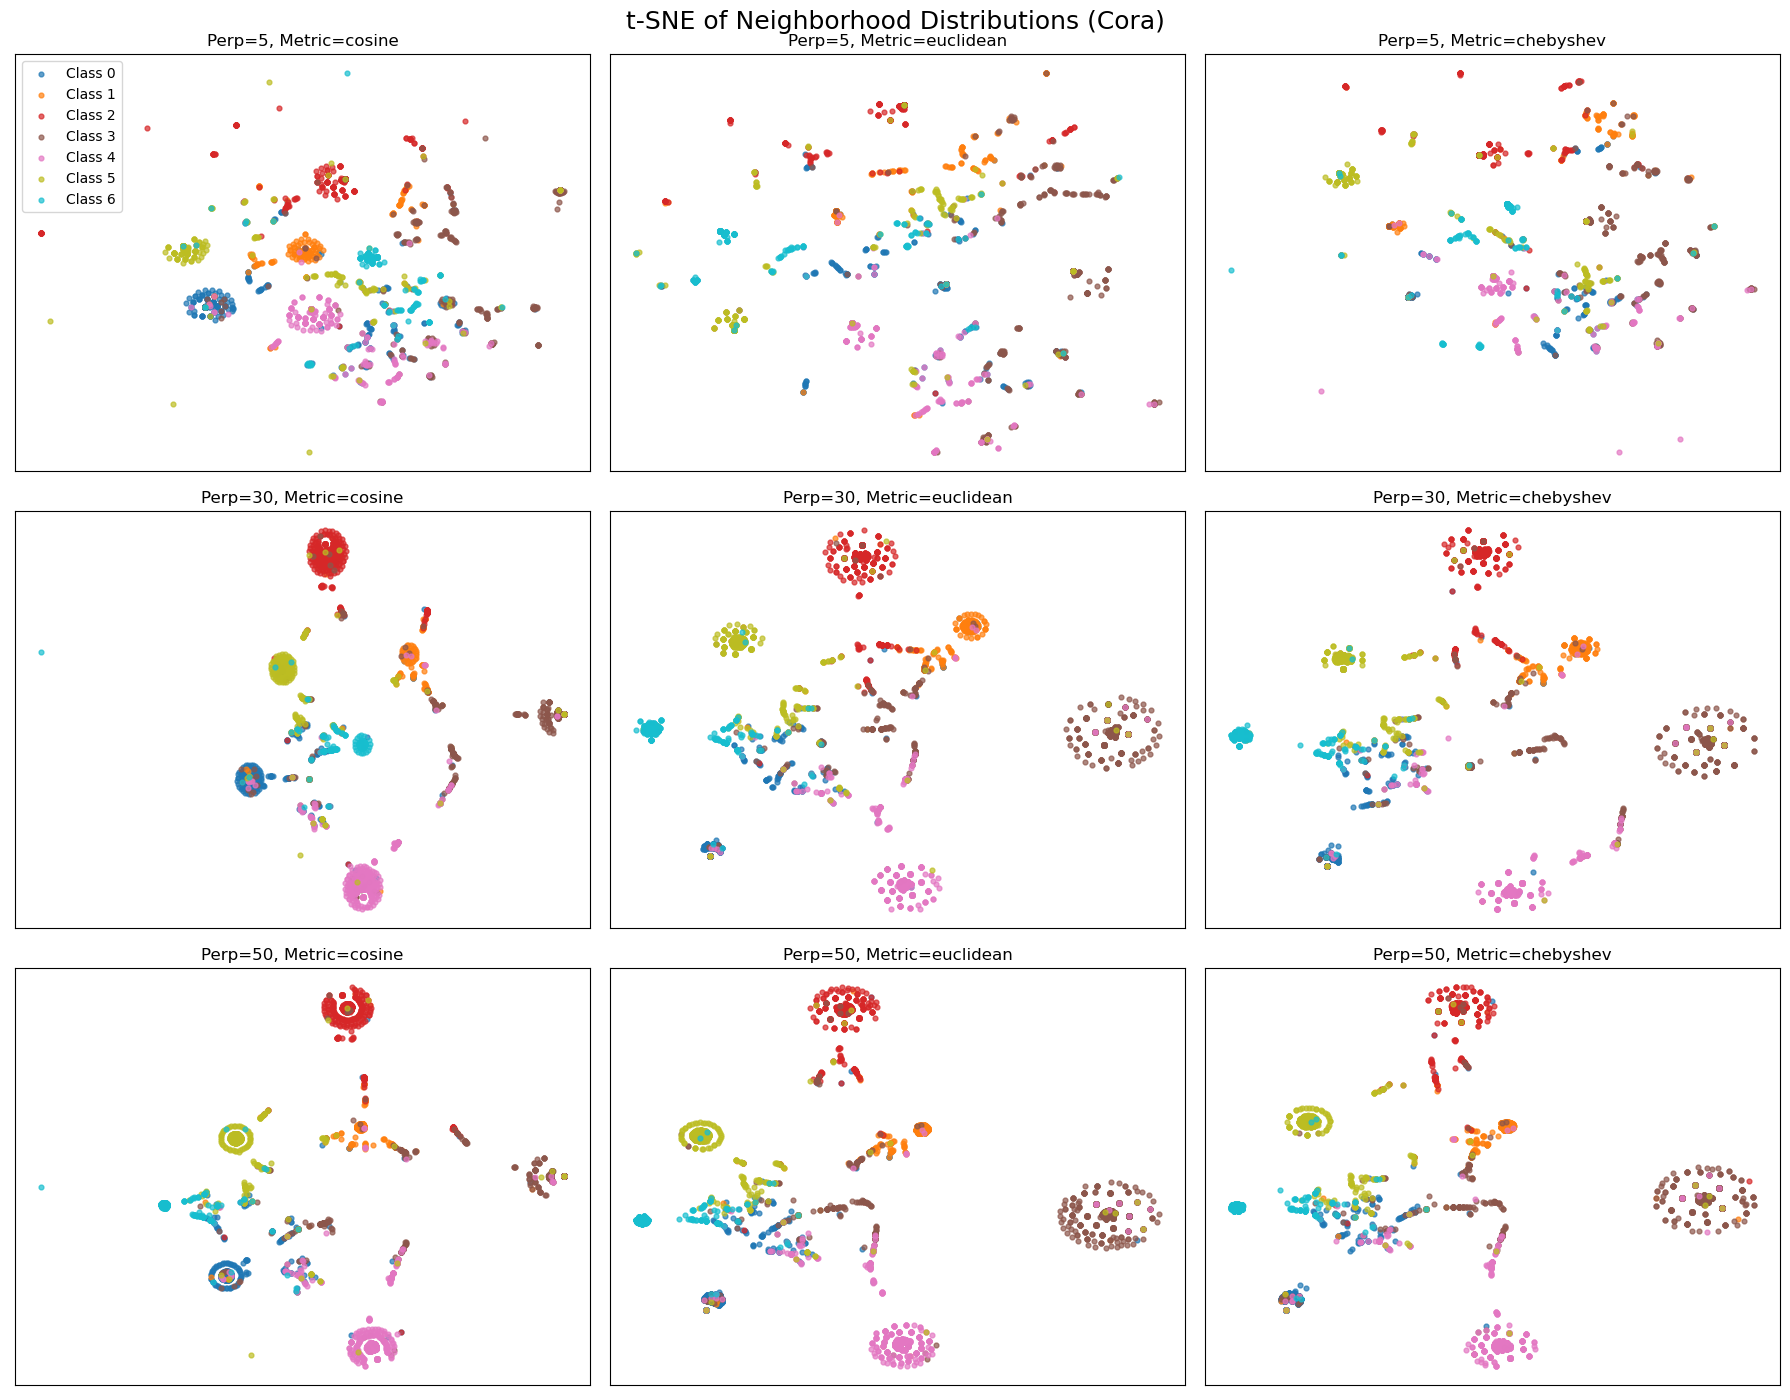

In [22]:
# --- 7. Mean and Variance of NDVs per Class ---

ndv_means_per_class = {}
ndv_vars_per_class = {}

for cls in all_classes:
    class_indices = np.where(labels == cls)[0]
    ndvs = neighborhood_distributions[class_indices]  # shape: [num_nodes_in_class, num_classes]
    
    ndv_mean = ndvs.mean(axis=0)     # shape: [num_classes]
    ndv_var = ndvs.var(axis=0)       # shape: [num_classes]
    
    ndv_means_per_class[cls] = ndv_mean
    ndv_vars_per_class[cls] = ndv_var

# Print class-wise NDV means
print("\n--- Mean of Neighborhood Distribution Vectors (NDVs) per Class ---")
for cls, mean_vec in ndv_means_per_class.items():
    print(f"Class {cls}: {np.round(mean_vec, 3)}")

# Print class-wise NDV variances
print("\n--- Variance of NDVs per Class ---")
for cls, var_vec in ndv_vars_per_class.items():
    print(f"Class {cls}: {np.round(var_vec, 3)}")



--- Mean of Neighborhood Distribution Vectors (NDVs) per Class ---
Class 0: [0.743 0.029 0.014 0.083 0.05  0.037 0.043]
Class 1: [0.04  0.769 0.062 0.08  0.02  0.028 0.002]
Class 2: [0.01  0.025 0.917 0.032 0.001 0.014 0.001]
Class 3: [0.055 0.02  0.016 0.839 0.051 0.015 0.004]
Class 4: [0.058 0.014 0.002 0.064 0.849 0.011 0.003]
Class 5: [0.058 0.017 0.03  0.051 0.018 0.786 0.04 ]
Class 6: [0.113 0.001 0.003 0.022 0.006 0.067 0.788]

--- Variance of NDVs per Class ---
Class 0: [0.102 0.019 0.006 0.033 0.02  0.014 0.019]
Class 1: [0.023 0.1   0.034 0.041 0.012 0.01  0.001]
Class 2: [0.003 0.008 0.039 0.016 0.001 0.009 0.   ]
Class 3: [0.028 0.01  0.009 0.085 0.028 0.01  0.001]
Class 4: [0.035 0.008 0.001 0.035 0.085 0.004 0.001]
Class 5: [0.024 0.007 0.018 0.026 0.009 0.1   0.022]
Class 6: [0.039 0.    0.001 0.008 0.002 0.028 0.089]


In [28]:
from sklearn.metrics.pairwise import cosine_similarity

# Stack all class mean NDVs into a matrix: shape (num_classes, num_classes)
ndv_mean_matrix = np.stack([ndv_means_per_class[c] for c in all_classes], axis=0)

# Compute cosine similarity matrix
cos_sim_matrix = cosine_similarity(ndv_mean_matrix)
print((cos_sim_matrix>.3).sum())
# Print similarity matrix
print("\n--- Cosine Similarity Between Mean NDVs of Classes ---")
for i, row in enumerate(cos_sim_matrix):
    row_str = "  ".join([f"{val:.3f}" for val in row])
    print(f"Class {i}:  {row_str}")


7

--- Cosine Similarity Between Mean NDVs of Classes ---
Class 0:  1.000  0.105  0.035  0.182  0.143  0.134  0.204
Class 1:  0.105  1.000  0.111  0.133  0.054  0.071  0.017
Class 2:  0.035  0.111  1.000  0.056  0.007  0.058  0.008
Class 3:  0.182  0.133  0.056  1.000  0.140  0.090  0.043
Class 4:  0.143  0.054  0.007  0.140  1.000  0.046  0.023
Class 5:  0.134  0.071  0.058  0.090  0.046  1.000  0.146
Class 6:  0.204  0.017  0.008  0.043  0.023  0.146  1.000


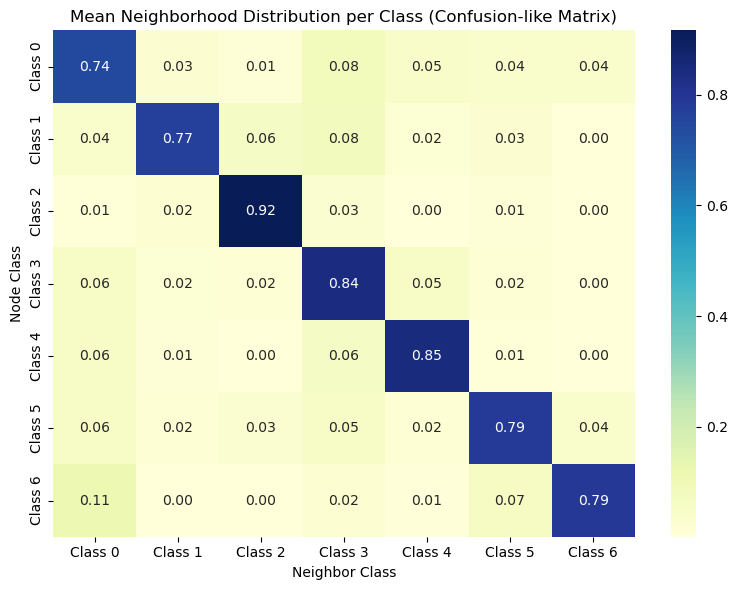

In [23]:
import seaborn as sns

# Convert dict to 2D numpy array
confusion_like_matrix = np.array([ndv_means_per_class[c] for c in all_classes])

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_like_matrix, annot=True, fmt=".2f", cmap="YlGnBu",
            xticklabels=[f'Class {i}' for i in all_classes],
            yticklabels=[f'Class {i}' for i in all_classes])
plt.title("Mean Neighborhood Distribution per Class (Confusion-like Matrix)")
plt.xlabel("Neighbor Class")
plt.ylabel("Node Class")
plt.tight_layout()
plt.show()


In [115]:

coo = s.tocoo()

for row, col, value in zip(coo.row, coo.col, coo.data):
    print(f"Row {row}, Col {col} = {value}")

Row 0, Col 306 = 1.0
Row 0, Col 542 = 1.0
Row 0, Col 1144 = 1.0
Row 0, Col 1770 = 1.0
Row 0, Col 2080 = 1.0


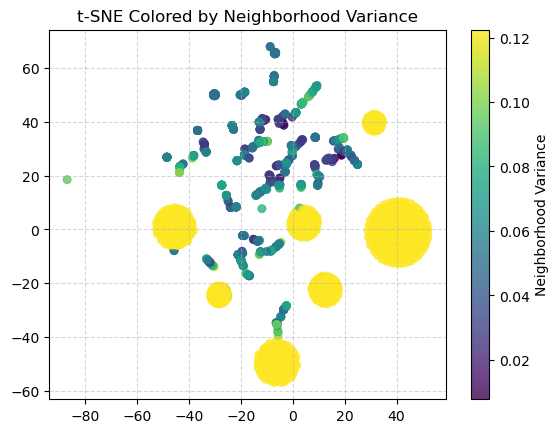

In [16]:
plt.scatter(tsne_results[:, 0], tsne_results[:, 1],
            c=variances, cmap='viridis', s=30,  # Fixed size
            alpha=0.8)
plt.colorbar(label='Neighborhood Variance')
plt.title('t-SNE Colored by Neighborhood Variance')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Saved: results_figs/chameleon_gcn.png
Saved: results_figs/chameleon_gcn.pdf


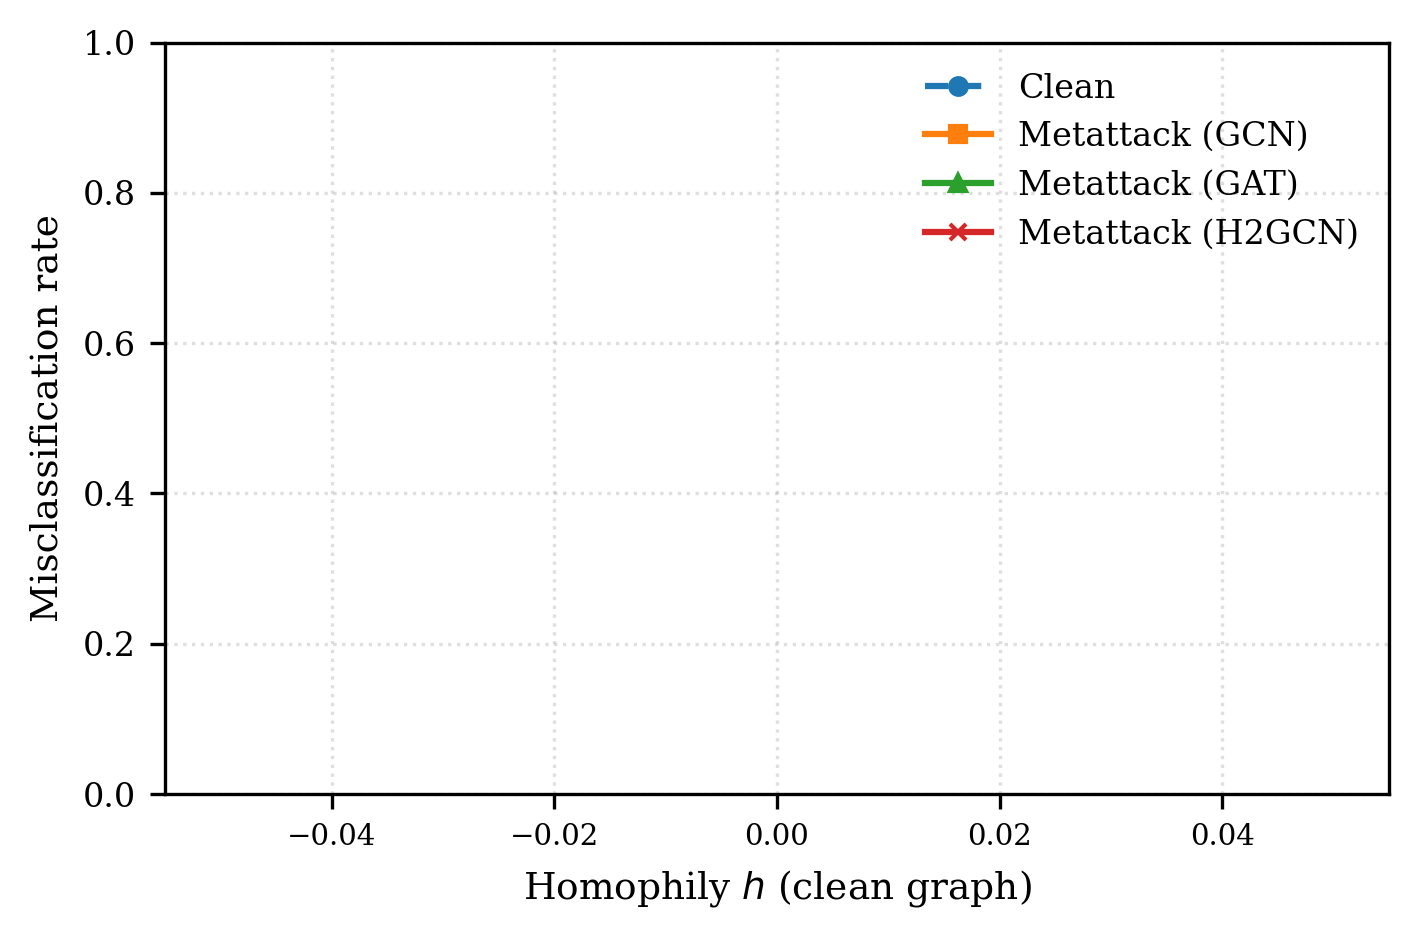

In [26]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===========================
# Matplotlib style
# ===========================
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 9,
    "font.family": "serif",
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.4,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
FIGSIZE = (4.8, 3.2)

def _clean_homophily_lookup(df: pd.DataFrame) -> pd.DataFrame:
    clean_df = df[df["attack_model"].str.lower() == "clean"].copy()
    if "homophily" not in clean_df.columns:
        raise ValueError("CSV must contain 'homophily' for clean runs.")
    return (
        clean_df.groupby("K", as_index=False)[["homophily"]]
        .mean()
        .rename(columns={"homophily": "h_clean"})
    )

def plot_line_misclf_vs_homophily(df: pd.DataFrame, out_dir="results_figs", out_name="fig1_line"):
    """Figure 1: Line plot of mean misclassification vs clean homophily.
    """
    os.makedirs(out_dir, exist_ok=True)
    clean_h_df = _clean_homophily_lookup(df)

    # Normalize text columns for robust filtering
    df = df.copy()
    if "attack_model" in df.columns:
        df["attack_model"] = df["attack_model"].astype(str).str.lower()
    if "model" in df.columns:
        df["model"] = df["model"].astype(str).str.lower()

    # 1) Clean curve
    clean_mean = (
        df[df["attack_model"] == "clean"]
        .groupby("K", as_index=False)["misclassification_rate"].mean()
        .merge(clean_h_df, on="K", how="left")
        .sort_values("h_clean")
    )

    # 2) Attacked curve evaluated with GCN
    meta_gcn_mean = (
        df[(df["attack_model"] == "metattack") & (df["model"] == "gcn")]
        .groupby("K", as_index=False)["misclassification_rate"].mean()
        .merge(clean_h_df, on="K", how="left")
        .sort_values("h_clean")
    )

    # 3) Attacked curve evaluated with GAT
    meta_gat_mean = (
        df[(df["attack_model"] == "metattack") & (df["model"] == "gat")]
        .groupby("K", as_index=False)["misclassification_rate"].mean()
        .merge(clean_h_df, on="K", how="left")
        .sort_values("h_clean")
    )

    meta_h2gcn_mean = (
        df[(df["attack_model"] == "metattack") & (df["model"] == "h2gcn")]
        .groupby("K", as_index=False)["misclassification_rate"].mean()
        .merge(clean_h_df, on="K", how="left")
        .sort_values("h_clean")
    )

    fig, ax = plt.subplots(figsize=FIGSIZE)

    ax.plot(clean_mean["h_clean"], clean_mean["misclassification_rate"],
            marker="o", linestyle="--", label="Clean")

    ax.plot(meta_gcn_mean["h_clean"], meta_gcn_mean["misclassification_rate"],
            marker="s", linestyle="-", label="Metattack (GCN)")

    ax.plot(meta_gat_mean["h_clean"], meta_gat_mean["misclassification_rate"],
            marker="^", linestyle="-", label="Metattack (GAT)")

    ax.plot(meta_gat_mean["h_clean"], meta_h2gcn_mean["misclassification_rate"],
            marker="x", linestyle="-", label="Metattack (H2GCN)")
    

    ax.set_xlabel("Homophily $h$ (clean graph)")
    ax.set_ylabel("Misclassification rate")
    ax.set_ylim(0, 1)
    ax.legend(frameon=False)
    fig.tight_layout()

    for ext in ("png", "pdf"):
        path = os.path.join(out_dir, f"{out_name}.{ext}")
        fig.savefig(path, bbox_inches="tight")
        print(f"Saved: {path}")

def plot_bar_homophily_before_after(
    df: pd.DataFrame,
    out_dir: str = "results_figs",
    out_name: str = "fig_homophily_bar_added_edges"
):
    """
    Bar chart of homophily before (clean) vs after (Metattack).
    X-axis: cumulative number of added edges (cumsum of K).
    Y-axis: homophily.
    Bars are grouped (before vs after) per cumulative step.
    """
    os.makedirs(out_dir, exist_ok=True)

    # Clean
    clean = (
        df[df["attack_model"].str.lower() == "clean"]
        .groupby("K", as_index=False)["homophily"]
        .mean()
        .rename(columns={"homophily": "h_before"})
    )

    # Metattack
    attacked = (
        df[df["attack_model"].str.lower() == "metattack"]
        .groupby("K", as_index=False)["homophily"]
        .mean()
        .rename(columns={"homophily": "h_after"})
    )

    merged = clean.merge(attacked, on="K", how="inner").sort_values("K")
    if merged.empty:
        raise ValueError("No overlapping K values between clean and metattack to plot homophily.")

    merged["num_added_edges"] = merged["K"].cumsum()

    x = np.arange(len(merged))
    width = 0.35

    fig, ax = plt.subplots(figsize=FIGSIZE)

    ax.bar(x - width/2, merged["h_before"], width, label="Before (clean)")
    ax.bar(x + width/2, merged["h_after"],  width, label="After (Metattack)")

    ax.set_xticks(x)
    ax.set_xticklabels([str(int(val)) for val in merged["num_added_edges"]])
    ax.set_xlabel("Number of added edges")
    ax.set_ylabel("Homophily $h$")
    ax.set_ylim(0, 1)
    ax.legend(frameon=False)
    fig.tight_layout()

    for ext in ("png", "pdf"):
        path = os.path.join(out_dir, f"{out_name}.{ext}")
        fig.savefig(path, bbox_inches="tight")
        print(f"Saved: {path}")

def plot_budget_h2gcn():
    budget_file = 'budget_cora.csv'
    df1 = pd.read_csv(budget_file)

    # we have 5% and clean classification here
    clean_df = pd.read_csv('result_h2gcn.csv')

    clean_df = clean_df[clean_df['seed']==33]

    print(clean_df.head())
    

plot_budget_h2gcn()


In [31]:
def plot_metattack_misclf_chameleon(
    df: pd.DataFrame,
    group_by: str = "K",                      # or "seed"
    filter_model: str | None = None,          # e.g., "gcn", "gat", "h2gcn" or None to aggregate across models
    out_dir: str = "results_figs",
    out_name: str = "chameleon_metattack_misclf"
):
    """
    Plot mean misclassification rate of Metattack on the Chameleon dataset,
    grouped by `group_by` (either 'K' or 'seed'). Ignores budget.

    Parameters
    ----------
    df : pd.DataFrame
        Combined results dataframe.
        Expected columns: ['dataset', 'attack_model', 'misclassification_rate', group_by, ('model' optional)]
    group_by : str
        'K' or 'seed'. The x-axis will be this column (sorted).
    filter_model : str | None
        If provided (e.g., 'gcn', 'gat', 'h2gcn'), filter to that evaluation model only.
        If None, aggregate across whatever models are present.
    out_dir : str
        Output directory to save figures.
    out_name : str
        Basename of the saved figure (without extension).
    """
    if group_by not in df.columns:
        raise ValueError(f"`group_by='{group_by}'` not found in columns: {list(df.columns)}")

    os.makedirs(out_dir, exist_ok=True)

    # Normalize text columns (case-insensitive matching)
    d = df.copy()
    if "dataset" in d.columns:
        d["dataset"] = d["dataset"].astype(str).str.lower()
    if "attack_model" in d.columns:
        d["attack_model"] = d["attack_model"].astype(str).str.lower()
    if "model" in d.columns:
        d["model"] = d["model"].astype(str).str.lower()

    # Filter: dataset=Chameleon, attack_model=metattack
    mask = (d.get("dataset", "chameleon") == "chameleon") & (d["attack_model"] == "metattack")
    if filter_model is not None and "model" in d.columns:
        mask &= (d["model"] == str(filter_model).lower())

    sub = d[mask].copy()
    if sub.empty:
        raise ValueError("No rows found for Metattack on Chameleon with the given filters.")

    # Group and compute mean misclassification rate
    g = (
        sub.groupby(group_by, as_index=False)["misclassification_rate"]
        .mean()
        .sort_values(group_by)
    )

    # Plot
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(
        g[group_by],
        g["misclassification_rate"],
        marker="o",
        linestyle="-",
        label=f"Metattack (grouped by {group_by})" if filter_model is None else f"Metattack ({filter_model}, by {group_by})"
    )

    ax.set_xlabel(group_by)
    ax.set_ylabel("Misclassification rate")
    ax.set_ylim(0, 1)
    ax.legend(frameon=False)
    fig.tight_layout()

    for ext in ("png", "pdf"):
        path = os.path.join(out_dir, f"{out_name}_{group_by}{'' if filter_model is None else f'_{filter_model}'}." + ext)
        fig.savefig(path, bbox_inches="tight")
        print(f"Saved: {path}")

# if __name__ == "__main__":
#     #FILE_PATHS = ["result.csv", "result_gat.csv", "result_h2gcn.csv"]
#     FILE_PATHS = ['chameleon_gcn.csv']
#     data = pd.DataFrame()
#     for file in FILE_PATHS:
#         df = pd.read_csv(file)
#         data = pd.concat([data, df], ignore_index=True)
#     plot_metattack_misclf_chameleon(data, out_name='chameleon_gcn')
#     #plot_bar_homophily_before_after(df)


In [32]:
## run on clean dataset

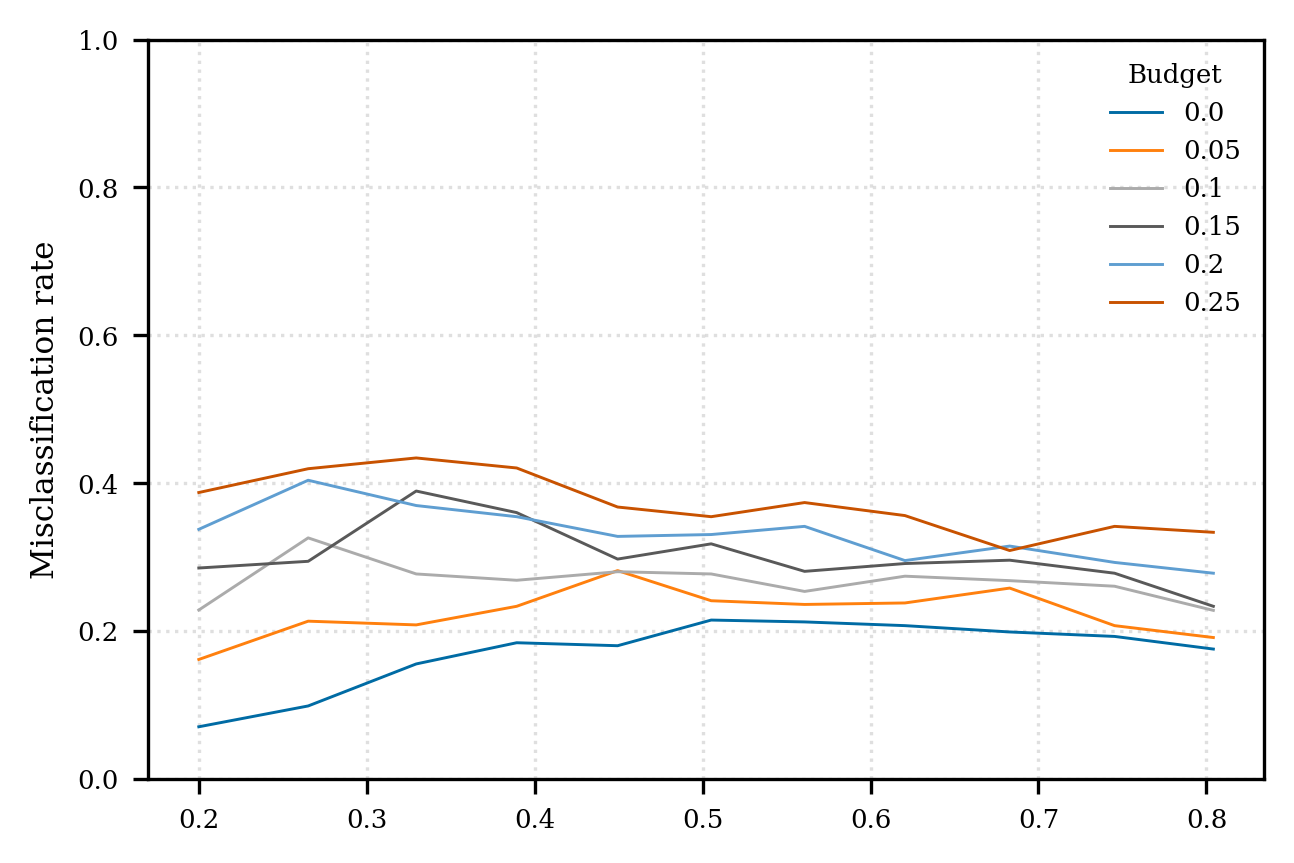

In [85]:
file = 'h2gcn_budget.csv'
df = pd.read_csv(file)
plt.style.use('tableau-colorblind10')
x = df['K'].unique()
x = df[df['attack_model']=='clean'].sort_values(by='K')['homophily']
fig, ax = plt.subplots(figsize=FIGSIZE)

ax.set_ylim(0, 1)
ax.set_ylabel("Misclassification rate", fontsize='small')

for budget in sorted(df['budget'].unique()):
    y = df[df['budget']==budget].sort_values(by='K')['misclassification_rate']
    ax.plot(x,y, label=f'{budget}', linewidth=0.7)

ax.tick_params(which='major', axis='both', labelsize='x-small')
ax.legend(title='Budget',frameon=False, fontsize='x-small',title_fontsize='x-small',)
plt.show()
plt.close()



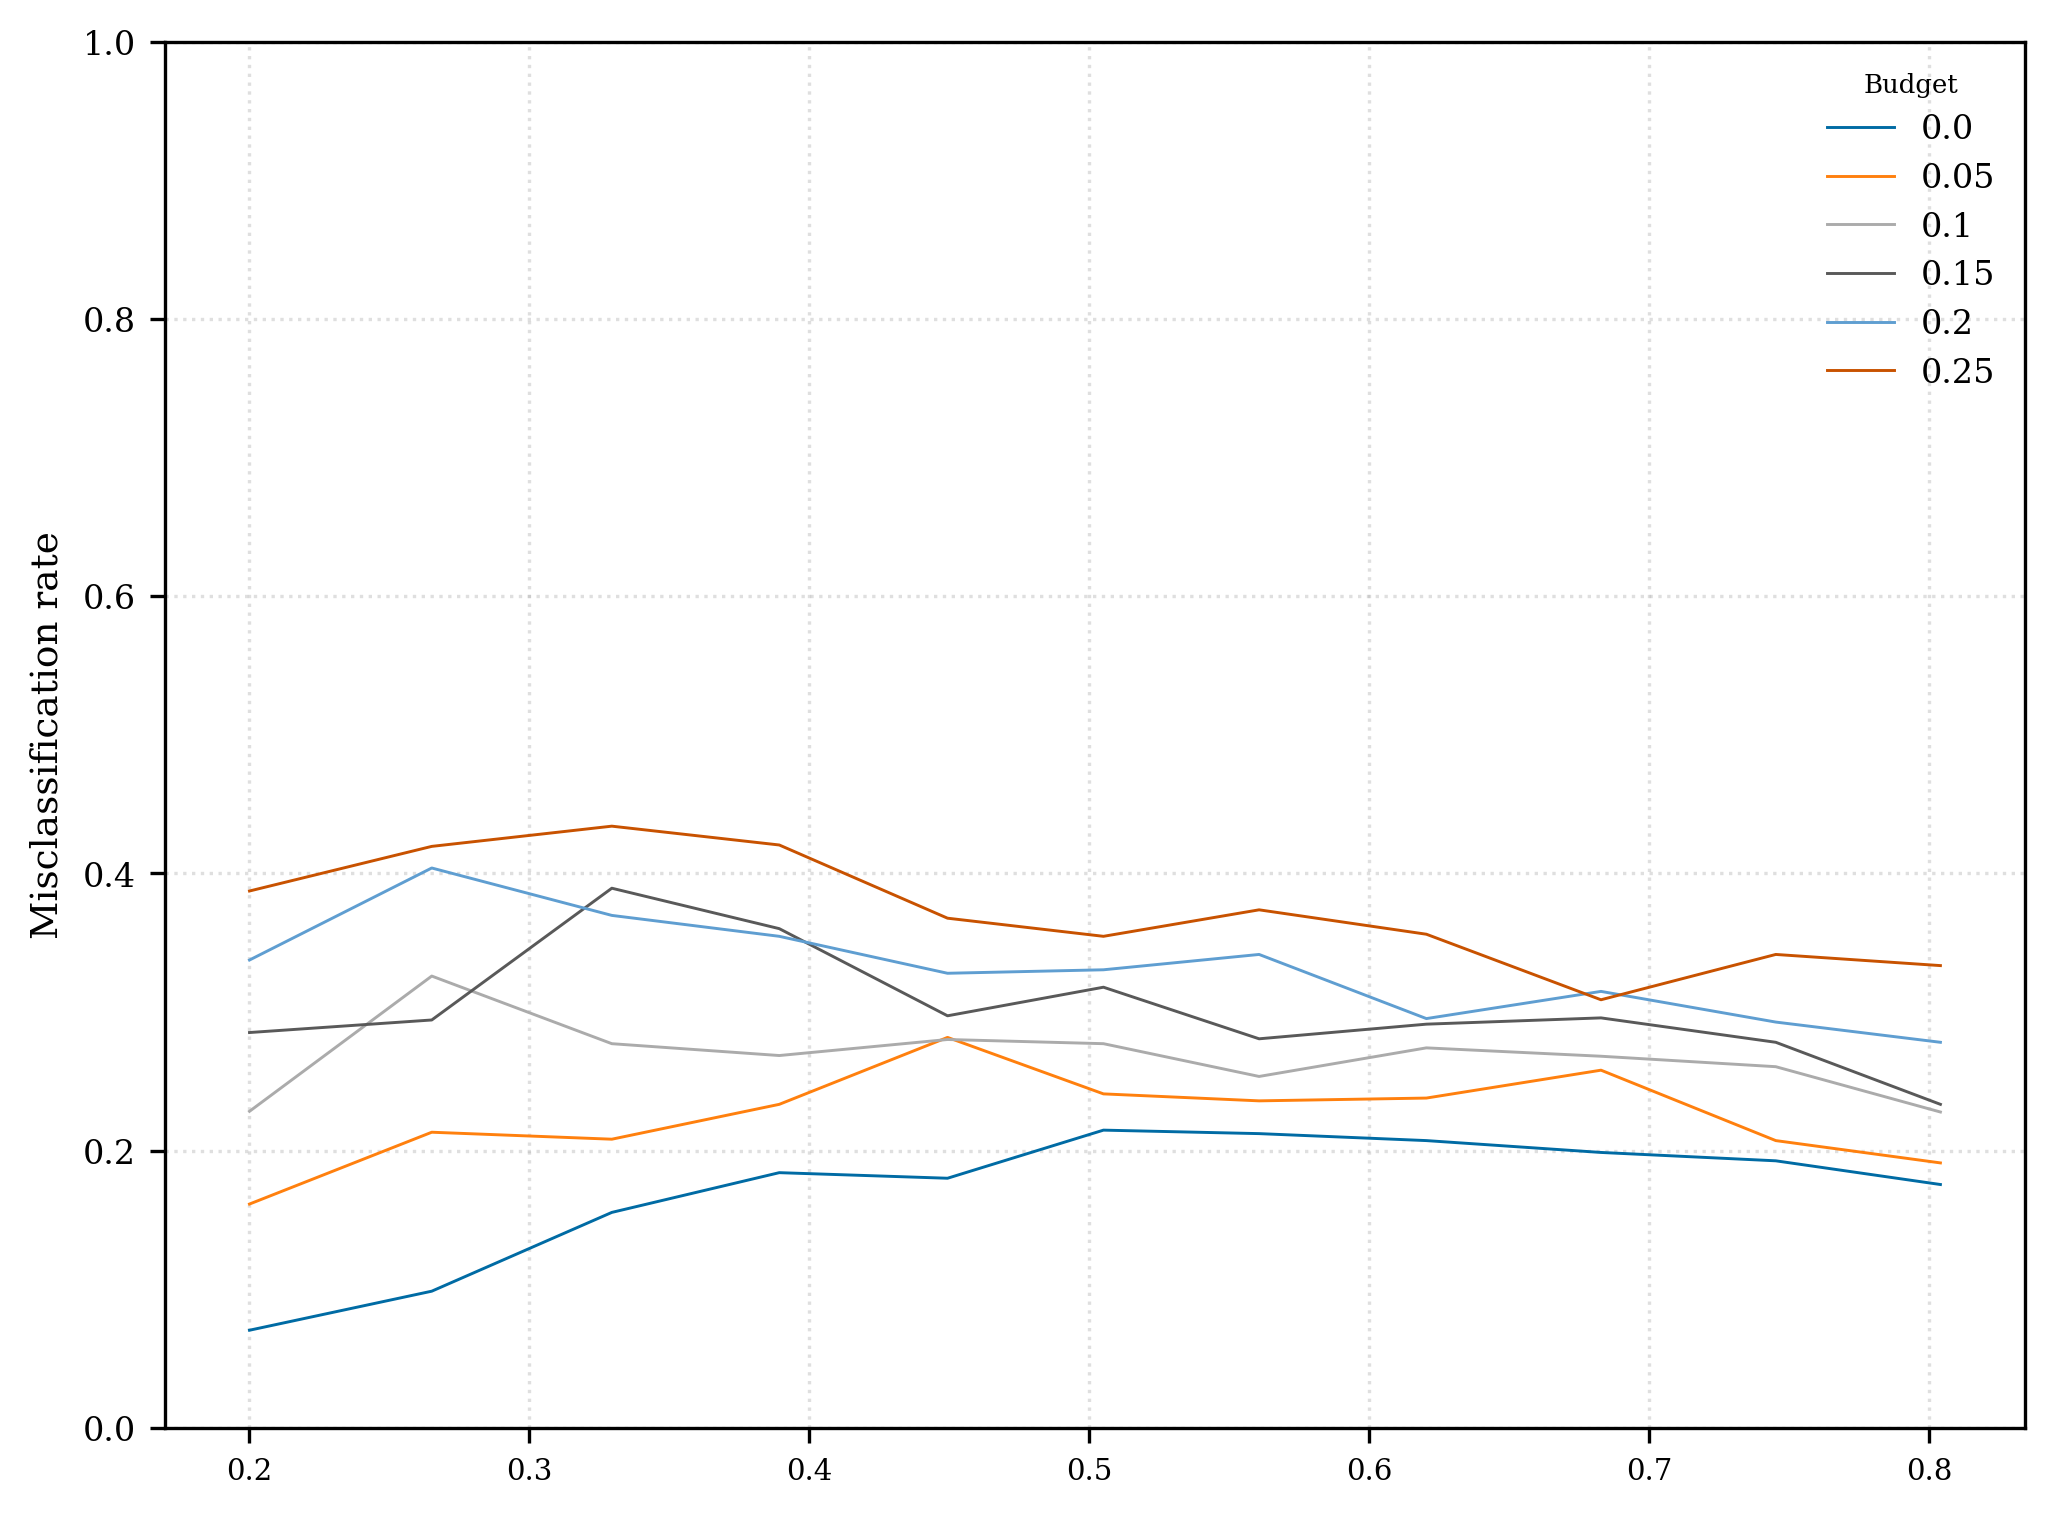

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


# The following lines are no longer needed because the style is global
# ax.tick_params(which='major', axis='both', labelsize='x-small')
# ax.legend(title='Budget',frameon=False, fontsize='x-small',title_fontsize='x-small',)

plt.show()
plt.close()